In [34]:
import numpy as np
import time
from os import path
import os
import sys
from pyuvdata import UVData
import pyuv_helper as ph
sys.path.insert(0,path.expanduser("~/albatros_analysis"))
from scripts.orbcomm import sat_utils as su
from scripts.orbcomm import figures as fgs_o
from src.utils import orbcomm_utils as outils
import psutil
import matplotlib.pyplot as plt
import json

In [7]:
def print_mem(process, label):
    mem = process.memory_info().rss / (1024**2)
    print(f"{label}: {mem:.2f} MB")

def load_pyuv(disk_path, **kwargs):
    uv = UVData()
    p = psutil.Process(os.getpid())
    t0 = time.time()

    mem1 = p.memory_info().rss / (1024**2)
    uv.read_uvh5(disk_path, **kwargs)
    mem2 = p.memory_info().rss / (1024**2)

    t1 = time.time()
    print(f"READ TIME: {t1 - t0:.3f} s")
    print(f"MEMORY: {mem2 - mem1:.4f} MB")
    print(f'DATA ARR SIZE: {uv.data_array.nbytes/(1024**2)} MB')
    print(f'DATA SHAPE: {uv.data_array.shape}')
    return uv

In [63]:
config_path = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test.json'

#disk_path = '/scratch/thomasb/xcorr_all_ant_1bit_1753132830_1753133200_512_64_344_260_280.pyuv'
disk_path = '/scratch/thomasb/xcorr_all_ant_1bit_1753216650_1753217000_512_64_325_1834_1852.pyuv'

with open(config_path, "r") as f:
    config = json.load(f)
ant_names, ant_coords, dir_parents, spec_offsets = [], [], [], []
# Call get_starting_index for all antennas except reference
for i, (ant, details) in enumerate(config["antennas"].items()):
    dir_parents.append(details["path"])
    spec_offsets.append(details["clock_offset"])
    ant_names.append(details["name"])
    ant_coords.append(details["coordinates"])

ant_numbers = np.array([int(name.split()[1]) for name in ant_names])
init_t = config["correlation"]["start_timestamp"]
end_t = config["correlation"]["end_timestamp"]
chanstart = config["frequency"]["start_channel"]
chanend = config["frequency"]["end_channel"]
osamp = config["correlation"]["osamp"]
pfb_size = config["correlation"]["pfb_size"]
new_acclen = config["correlation"]["new_acclen"]

new_chunk_len = (new_acclen*4096*osamp)/250e6

In [11]:
#check the metadata
uv_disk = UVData()
uv_disk.read_uvh5(disk_path, read_data=False)
uv_disk.check(check_extra = True)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15162.725505130295 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15162.725505130295 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


True

In [12]:
#overall read time
uv_all = load_pyuv(disk_path)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15162.725505130295 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


READ TIME: 4.005 s
MEMORY: 1690.8945 MB
DATA ARR SIZE: 1279.6875 MB
DATA SHAPE: (18200, 1152, 4)


Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 9.277971457777312e-07, largest imaginary/real ratio was 3.1121744647021024e-09.


In [13]:
#fixed frequencies
uv_chans = load_pyuv(disk_path, freq_chans = np.arange(200, 800))

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15162.725505130295 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 6.312174036793294e-07, largest imaginary/real ratio was 3.1121744647021024e-09.


READ TIME: 43.258 s
MEMORY: 880.4062 MB
DATA ARR SIZE: 666.50390625 MB
DATA SHAPE: (18200, 600, 4)


In [14]:
uv_blts = load_pyuv(disk_path, blt_inds = np.arange(1000, 6000))

READ TIME: 1.235 s
MEMORY: 467.9492 MB
DATA ARR SIZE: 351.5625 MB
DATA SHAPE: (5000, 1152, 4)


The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15161.757563894684 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 9.277971457777312e-07, largest imaginary/real ratio was 2.9260798637074856e-09.


In [15]:
uv_bltpol = load_pyuv(disk_path, bls = [(1,8)])

READ TIME: 2.243 s
MEMORY: 49.3438 MB
DATA ARR SIZE: 45.703125 MB
DATA SHAPE: (650, 1152, 4)


The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 2949.9434386074836 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


In [16]:
load_pyuv(disk_path, bls = [(1,8, 'xx')])

READ TIME: 2.864 s
MEMORY: 15.6250 MB
DATA ARR SIZE: 11.42578125 MB
DATA SHAPE: (650, 1152, 1)


The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 2949.9434386074836 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


In [75]:
data_all = uv_all.data_array
antnums = uv_all.telescope.antenna_numbers
ant1, ant2 = 1, 6
ant1_idx, ant2_idx = np.where(antnums == ant1)[0][0], np.where(antnums == ant2)[0][0]
coords1, coords2 = ant_coords[ant1_idx], ant_coords[ant2_idx]
name1, name2 = ant_names[ant1_idx], ant_names[ant2_idx]
bl_slice = uv_all.antpair2ind(ant1, ant2)
bl_12_data = data_all[bl_slice, :, 0]
bl_12_angle = np.angle(bl_12_data)

print(ant1, ant2)
print(ant1_idx, ant2_idx)
print(bl_12_data.shape)

1 6
0 4
(650, 1152)


170
1836.65625
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.07816886901855469
time taken pred 0.07940006256103516
MAX PHASE DIFFERENCE: 14.462672264344292


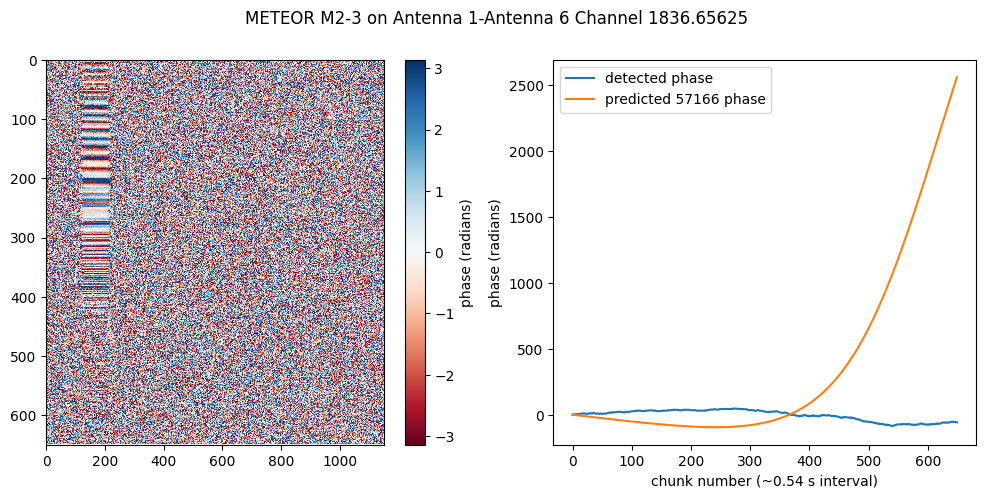

In [76]:
chan_new = 170
chan_old = 1834 + (chan_new/osamp)
print(chan_new)
print(chan_old)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'METEOR M2-3 on {name1}-{name2} Channel {chan_old}')

im = ax[0].imshow(bl_12_angle, aspect='auto', cmap='RdBu', interpolation='none')
#ax[0].set_xlabel("channel idx (~60 kHz interval)")
#ax[0].set_ylabel("chunk number (~0.5 s interval)")
cbar = fig.colorbar(im, ax=ax[0], orientation='vertical')
cbar.set_label("phase (radians)")

phase = np.unwrap(bl_12_angle[:, chan_new] - bl_12_angle[0, chan_new])
satID = 57166
pred_phase = outils.pred(coords1, 
                         coords2, 
                         init_t, 
                         end_t, 
                         chan_old, 
                         int(satID), 
                         v_acclen=new_acclen, 
                         T_SPECTRA = (4096*osamp)/250e6)[:len(phase)]

ax[1].plot(phase, label='detected phase')
ax[1].plot(pred_phase, label=f'predicted {satID} phase')
ax[1].set_xlabel(f"chunk number (~{np.round(new_chunk_len, decimals=2)} s interval)")
ax[1].set_ylabel("phase (radians)")


print('MAX PHASE DIFFERENCE:', np.max(np.diff(np.abs(pred_phase))))
ax[1].legend()

In [24]:
chan_idx = 1
vis_chan = bl_12_data[:, chan_idx]
vis_chan = vis_chan.ravel()

p_vis = np.angle(vis_chan)
#mean_amp = np.mean(np.abs(vis), axis=1)
#chan_s_idx = np.argmax(mean_amp)
#chan_b_idx = chanlist[chan_s_idx]
phase = np.unwrap(p_vis[:]) - p_vis[0] #zero the initial phase

#fig = fgs_o.makeplot_fringes_phase(coords, times, chan_big_idx, chanlist, vis_angle, phase, satmap,sats_present,v_acclen,T_SPECTRA = 4096/250e6)

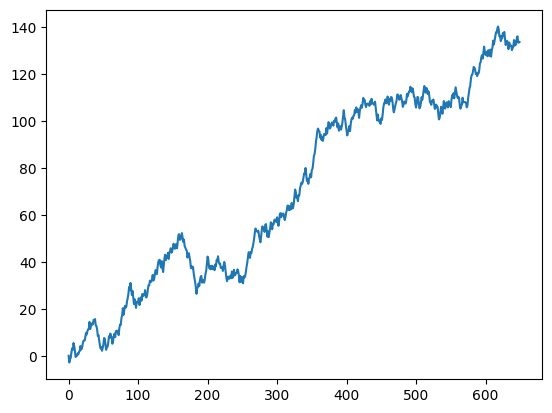

In [25]:
plt.plot(phase)

In [19]:
vchk = np.zeros((10, 5, 3), order="F")
for i in range(5):
    vchk[:,i,:] = i
print(vchk)

[[[0. 0. 0.]
  [1. 1. 1.]
  [2. 2. 2.]
  [3. 3. 3.]
  [4. 4. 4.]]

 [[0. 0. 0.]
  [1. 1. 1.]
  [2. 2. 2.]
  [3. 3. 3.]
  [4. 4. 4.]]

 [[0. 0. 0.]
  [1. 1. 1.]
  [2. 2. 2.]
  [3. 3. 3.]
  [4. 4. 4.]]

 [[0. 0. 0.]
  [1. 1. 1.]
  [2. 2. 2.]
  [3. 3. 3.]
  [4. 4. 4.]]

 [[0. 0. 0.]
  [1. 1. 1.]
  [2. 2. 2.]
  [3. 3. 3.]
  [4. 4. 4.]]

 [[0. 0. 0.]
  [1. 1. 1.]
  [2. 2. 2.]
  [3. 3. 3.]
  [4. 4. 4.]]

 [[0. 0. 0.]
  [1. 1. 1.]
  [2. 2. 2.]
  [3. 3. 3.]
  [4. 4. 4.]]

 [[0. 0. 0.]
  [1. 1. 1.]
  [2. 2. 2.]
  [3. 3. 3.]
  [4. 4. 4.]]

 [[0. 0. 0.]
  [1. 1. 1.]
  [2. 2. 2.]
  [3. 3. 3.]
  [4. 4. 4.]]

 [[0. 0. 0.]
  [1. 1. 1.]
  [2. 2. 2.]
  [3. 3. 3.]
  [4. 4. 4.]]]


In [3]:
print(18*64)

1152


In [ ]:
im = ax[0].imshow(vis_angle, aspect='auto', cmap='RdBu', interpolation='none')